# Aceiro — Detecção de fumaça

Treina um YOLO para detectar **fumaça** e gera o vídeo da demo do pitch.

**Antes de começar:** menu `Ambiente de execução` → `Alterar tipo de ambiente de execução` → **GPU T4** → Salvar.

Rode as células em ordem (Shift+Enter).

## 1. Instalar

In [ ]:
!pip install -q ultralytics roboflow
import torch
print('GPU disponivel:', torch.cuda.is_available())

GPU disponivel: True


In [ ]:
from google.colab import files
files.upload()   # envie o kaggle.json

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets download -d sayedgamal99/smoke-fire-detection-yolo
!unzip -q -o smoke-fire-detection-yolo.zip -d dataset

import yaml
cfg = yaml.safe_load(open('dataset/data.yaml'))
cfg['path'] = '/content/dataset/data'
cfg['train'] = 'train/images'
cfg['val'] = 'val/images'
cfg['test'] = 'test/images'
yaml.safe_dump(cfg, open('dataset/data.yaml', 'w'))
print(cfg)

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo
License(s): CC0-1.0
smoke-fire-detection-yolo.zip: Skipping, found more recently modified local copy (use --force to force download)
{'path': '/content/dataset/data', 'train': 'train/images', 'val': 'val/images', 'test': 'test/images', 'names': ['smoke', 'fire'], 'nc': 2, 'train_count': 14122, 'val_count': 3099, 'test_count': 4306}


## 3. Treinar

Leva de 20 a 50 minutos. Não feche a aba.

In [ ]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

results = model.train(
    data='dataset/data.yaml',          # <-- cola aqui o caminho que apareceu
    epochs=30,
    imgsz=640,
    batch=16,
    project='aceiro',
    name='fumaca',
    patience=10
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fumaca-2, nbs=64, nms=False, opset=None, opt

## 4. Ver os resultados

Gráficos.

pasta: /content/runs/detect/aceiro/fumaca-2


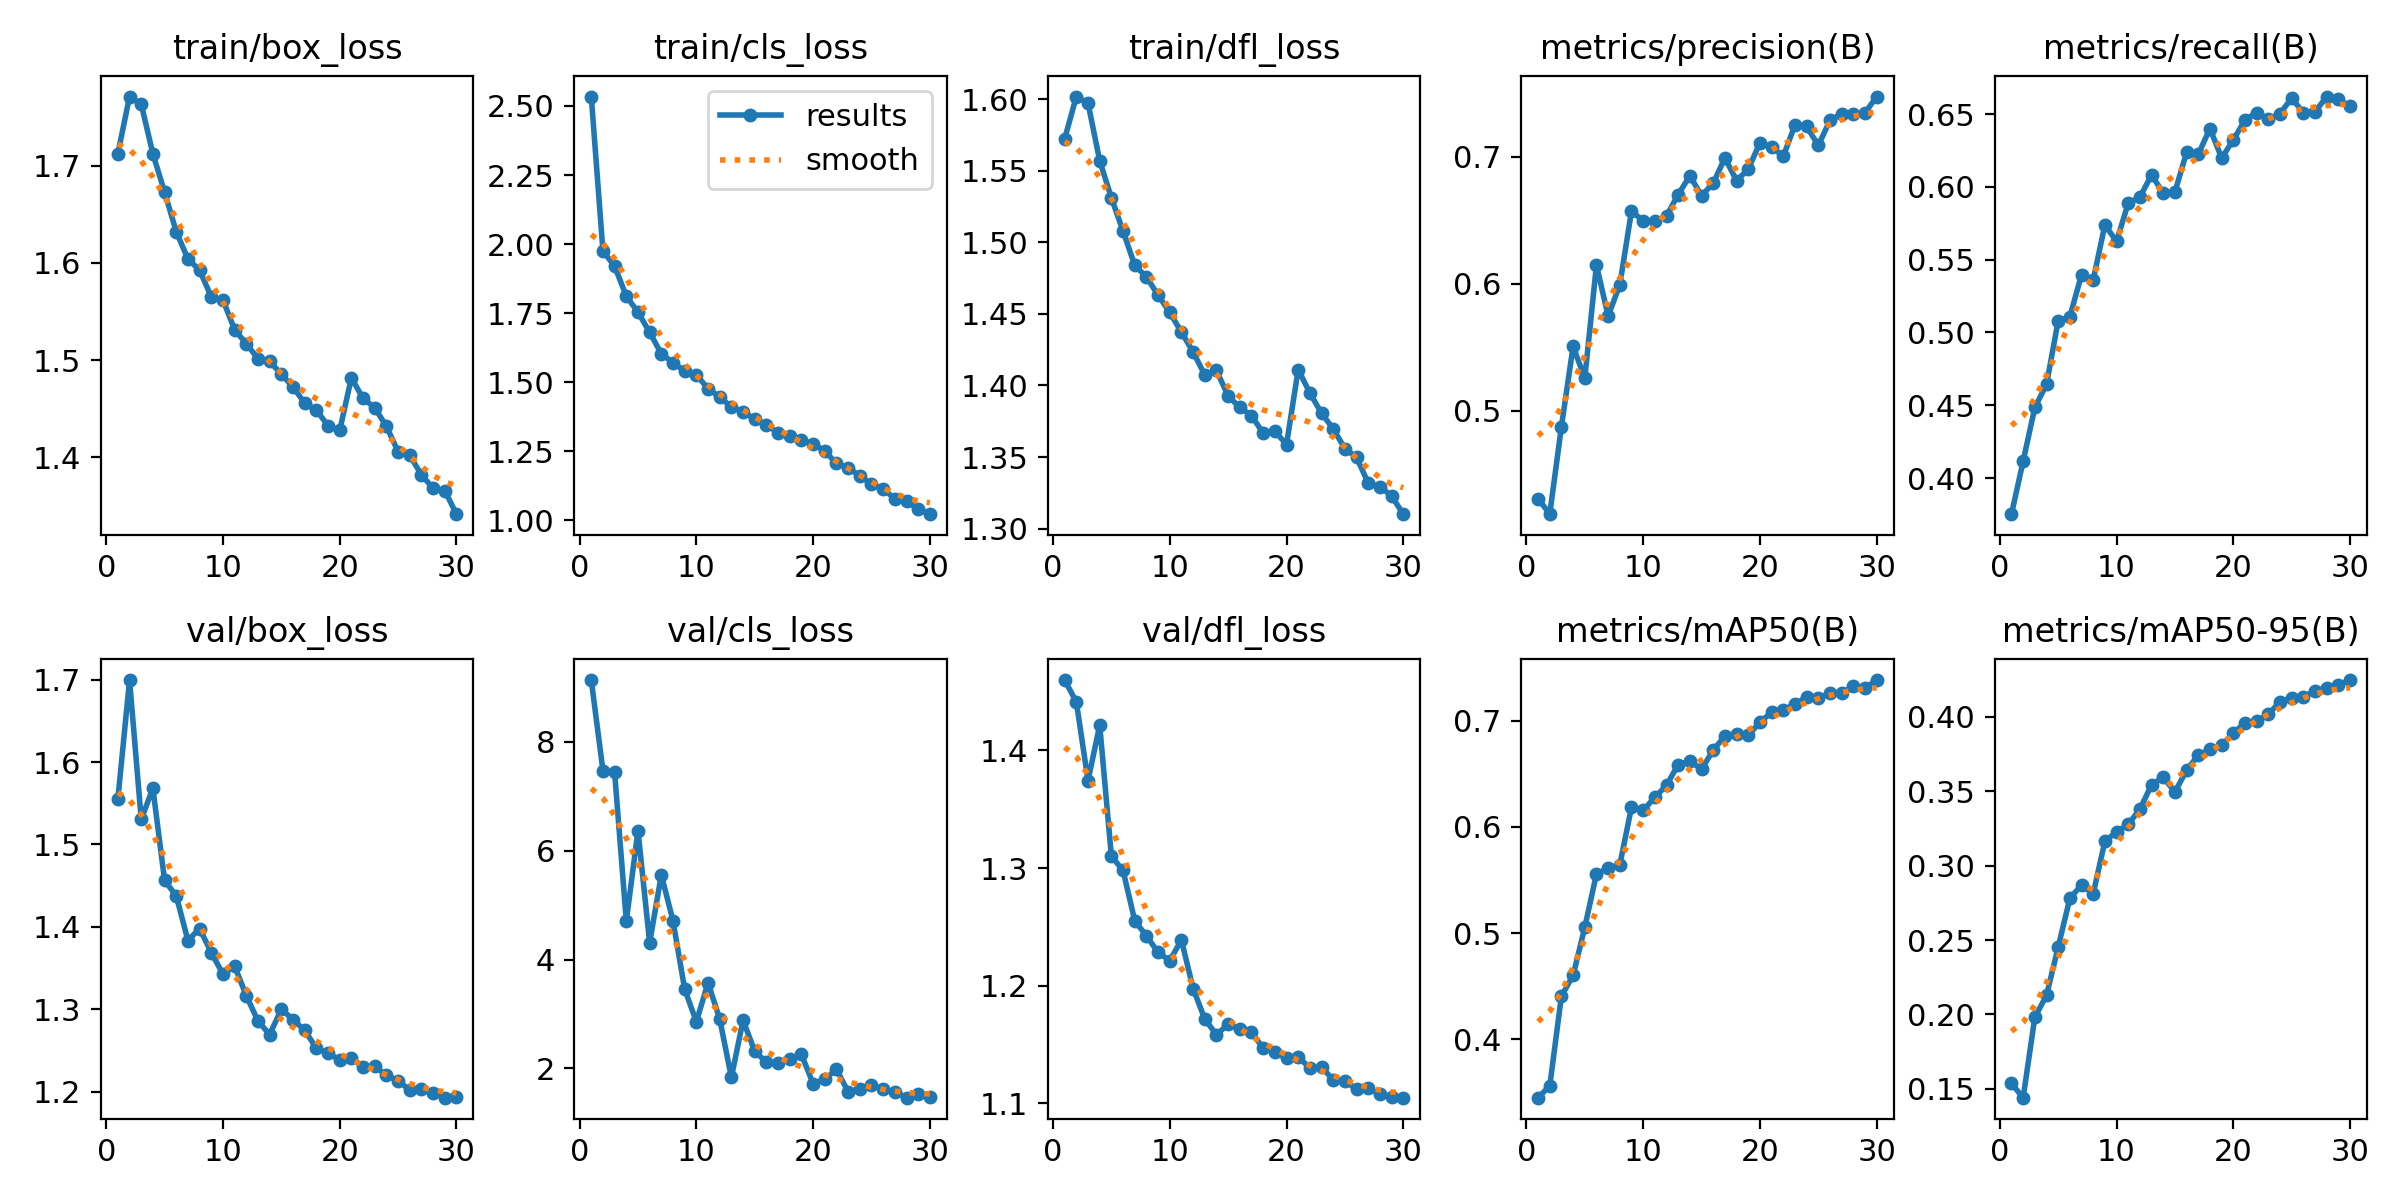

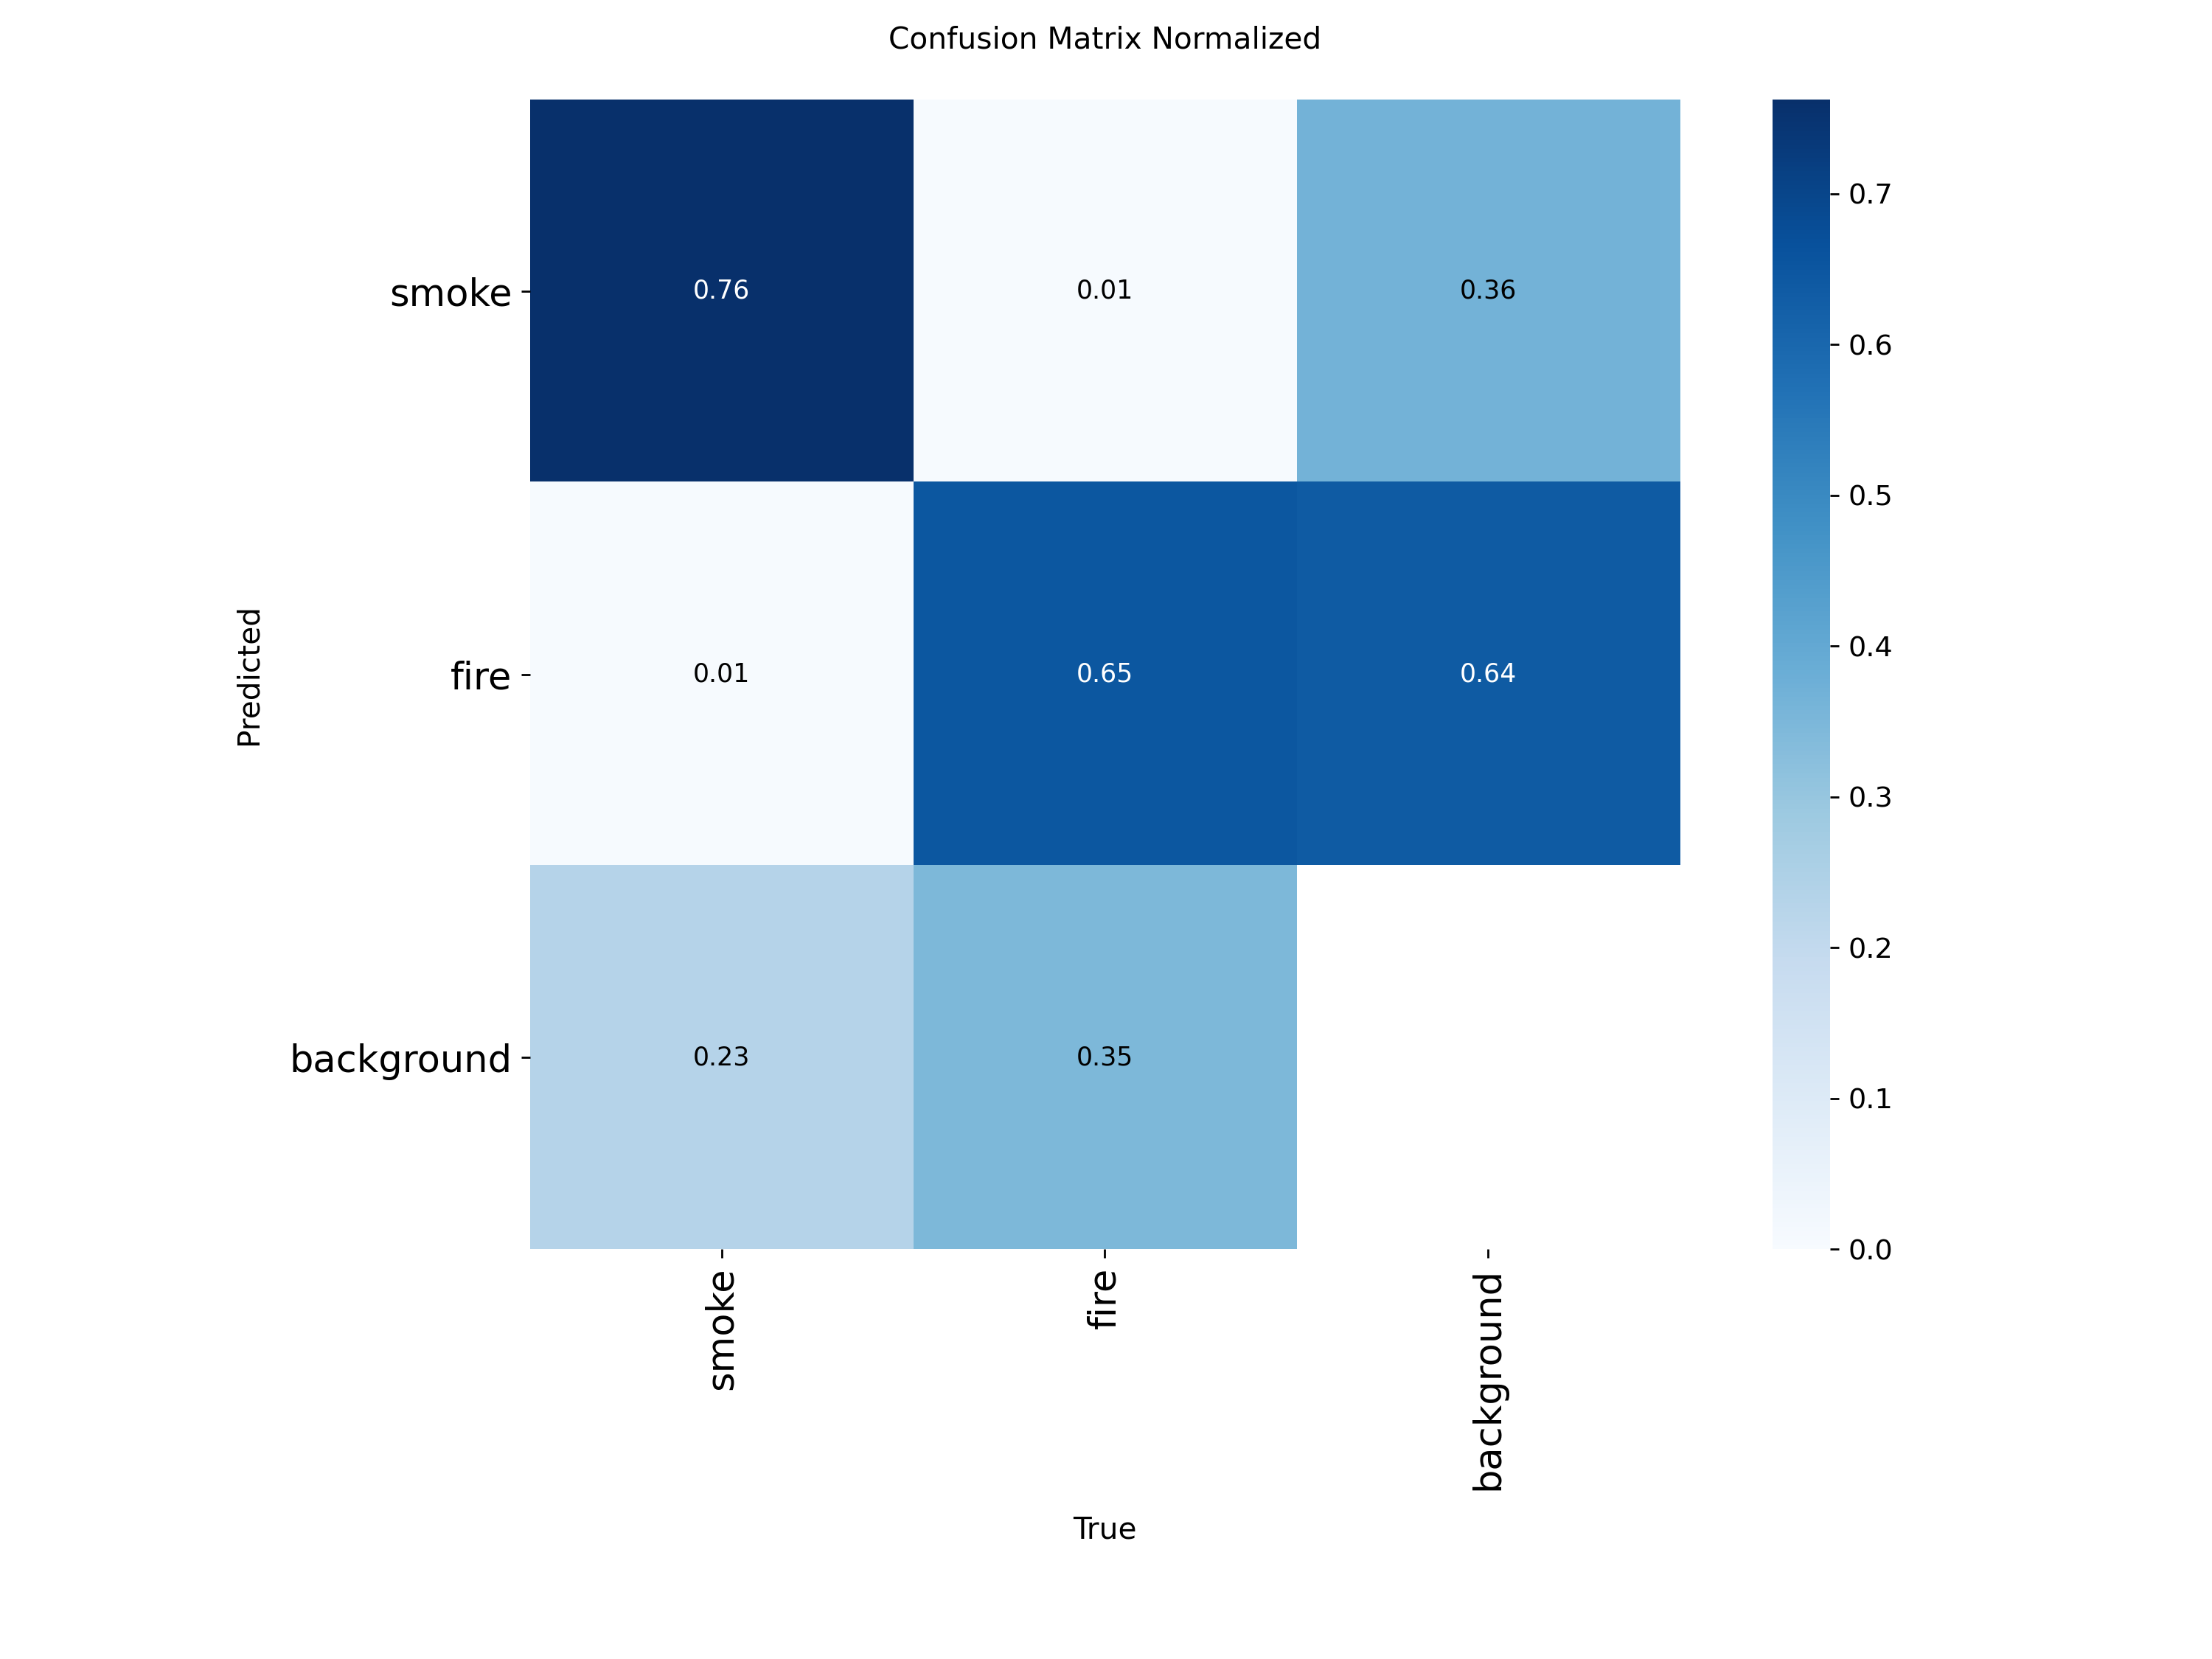

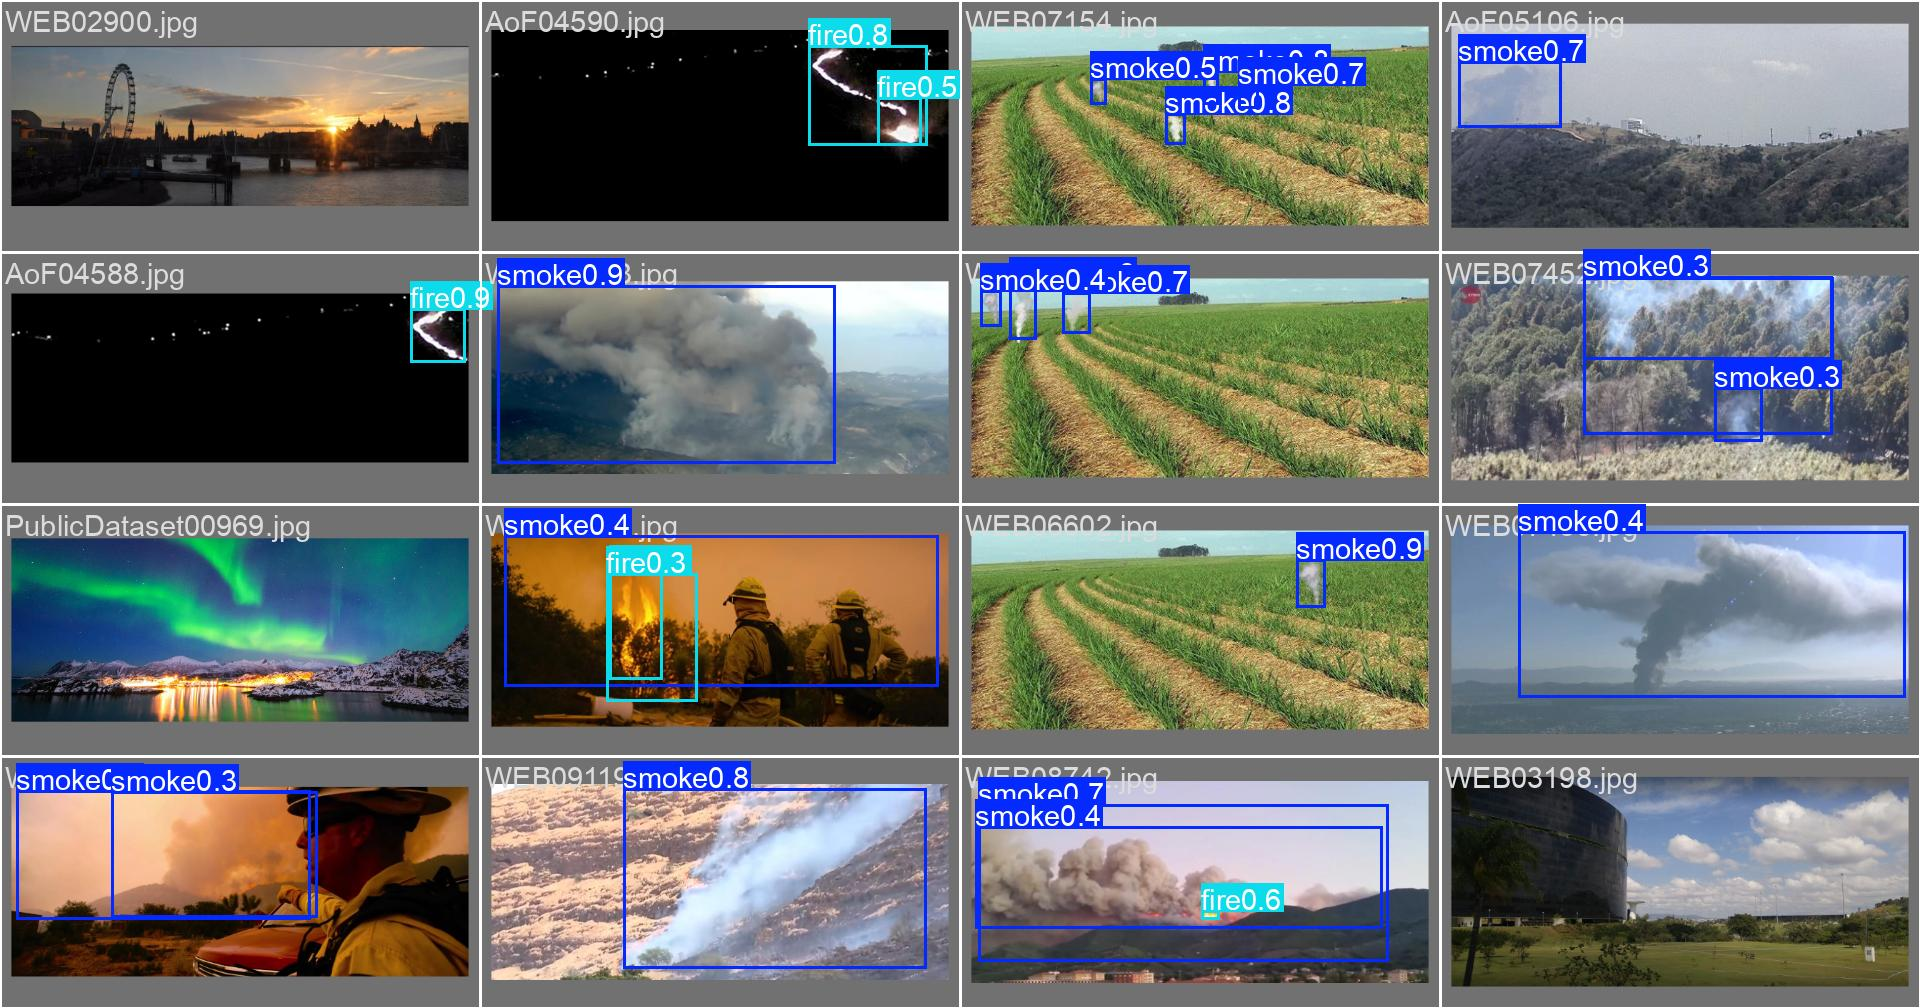

In [ ]:
import glob, os
from IPython.display import Image, display

PASTA = os.path.dirname(os.path.dirname(
    glob.glob('/content/runs/detect/**/weights/best.pt', recursive=True)[-1]))
print('pasta:', PASTA)

for arq in ['results.png', 'confusion_matrix_normalized.png', 'val_batch0_pred.jpg']:
    caminho = os.path.join(PASTA, arq)
    if os.path.exists(caminho):
        display(Image(caminho, width=900))

## 5. Enviar o vídeo de queimada

Rode a célula e escolha o arquivo do seu PC. Use um vídeo de 30 a 60 segundos com fumaça bem visível.

In [ ]:
from google.colab import files
enviado = files.upload()
VIDEO = list(enviado.keys())[0]
print('Arquivo:', VIDEO)

Saving incendiodet.mp4 to incendiodet.mp4
Arquivo: incendiodet.mp4


## 6. Rodar a detecção no vídeo

In [ ]:
melhor = YOLO(os.path.join(PASTA, 'weights/best.pt'))

melhor.predict(
    source=VIDEO,
    save=True,
    conf=0.35,
    line_width=3,
    project='aceiro',
    name='demo'
)

!ls aceiro/demo


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/949) /content/incendiodet.mp4: 384x640 1 smoke, 12.8ms
video 1/1 (frame 2/949) /content/incendiodet.mp4: 384x640 2 smokes, 14.5ms
video 1/1 (frame 3/949) /content/incendiodet.mp4: 384x640 1 smoke, 18.0ms
video 1/1 (frame 4/949) /content/incendiodet.mp4: 384x640 1 smoke, 11.8ms
video 1/1 (frame 5/949) /content/incendiodet.mp4: 384x640 1 smoke, 12.1ms
video 1/1 (frame 6/949) /content/incendiodet.mp4: 384x640 1 smoke, 12.0ms
video 1/1 (fr

## 7. Converter e baixar

A conversão é importante: sem ela o vídeo pode não tocar no PowerPoint.

In [ ]:
import glob
from google.colab import files

saida = glob.glob('/content/runs/detect/**/demo*/*', recursive=True)[0]
print('gerado:', saida)

!ffmpeg -y -loglevel error -i "{saida}" -vcodec libx264 -pix_fmt yuv420p -crf 23 aceiro_demo.mp4

files.download('aceiro_demo.mp4')

gerado: /content/runs/detect/aceiro/demo/incendiodet.avi


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Se o treino não der certo a tempo

Pule as células 2, 3 e 4 e rode a linha abaixo no lugar da célula 6. Use um modelo público de fumaça já treinado (procure `smoke detection yolo` no Roboflow Universe → aba **Model** → código de inferência).

No palco, a fala muda de "nosso modelo treinado" para "nossa arquitetura de detecção rodando" — honesto e ninguém percebe diferença num vídeo de 30 segundos.